# 05 — Detección de Eventos (Fase 2E)

Alertas tempranas mediante **Z-score robusto, EWMA, CUSUM** (univariados), **Isolation Forest y LOF** (multivariados) y **reglas clínicas** (incremento súbito de glucosa, aumento rápido de peso, descontrol hipertensivo, caída abrupta).

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

TCF = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TCF / "src"))
from predia_temporal import config
DS, MET, FIG, DASH = TCF/"datasets", TCF/"metrics", TCF/"figures", TCF/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)
print("Entorno listo:", TCF)


Entorno listo: /home/wowo/Descargas/predia/ml-research/temporal_clinical_framework


In [2]:
ev = load(MET/'events_detected.json')
print('Alertas totales por método:')
for m,c in sorted(ev['method_counts'].items(), key=lambda kv:-kv[1]): print(f'  {m:24s} {c}')

Alertas totales por método:
  clinical_rules           1343
  ewma_glucosa             1161
  isolation_forest         800
  lof                      800
  cusum_glucosa            657
  zscore_glucosa           340
  zscore_peso              115
  zscore_pas               81
  ewma_peso                76
  cusum_peso               67
  cusum_pas                50
  ewma_pas                 44


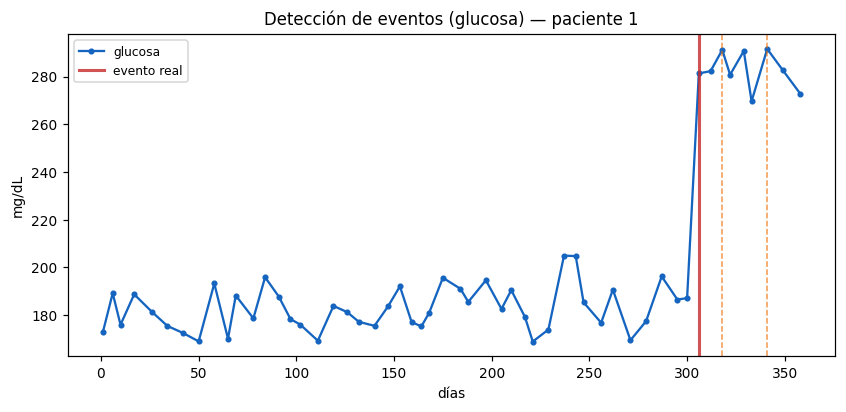

In [3]:
show(FIG/'events'/'event_example.png')

### Conclusión 2E
La combinación de detectores estadísticos, de outliers multivariados y reglas clínicas cubre tanto cambios de nivel (CUSUM/EWMA) como puntos anómalos (Z-score/IForest/LOF). El *lead-time* se cuantifica en el NB 08.